# Test Pipeline — Extract Frames → Denoising → Canny Edge Detection

Notebook này dùng để **test nhanh** các bước đã hoàn thiện trong pipeline (tới bước Canny):

```
Video → Extract Frames → Gaussian/Bilateral Denoising → Canny Edge Detection
```

Notebook import trực tiếp các module trong `src/` (không chạy qua CLI) để dễ debug và trực quan hóa kết quả từng bước.

> Đặt file này trong thư mục `VideoSuperResolution/notebooks/` để các đường dẫn tương đối hoạt động đúng.

## 0. Setup — import module & cấu hình đường dẫn

In [19]:
import sys
import os
from pathlib import Path

# notebooks/ nằm trong VideoSuperResolution/, nên project root là thư mục cha
PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"

for sub in ["extraction", "preprocessing", "feature", "segmentation", "utils"]:
    p = str(SRC_DIR / sub)
    if p not in sys.path:
        sys.path.insert(0, p)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("sys.path (đã thêm):", [p for p in sys.path if str(SRC_DIR) in p])

PROJECT_ROOT: d:\PYTHON\cv\CP_Vsions\VideoSuperResolution
sys.path (đã thêm): ['d:\\PYTHON\\cv\\CP_Vsions\\VideoSuperResolution\\src\\utils', 'd:\\PYTHON\\cv\\CP_Vsions\\VideoSuperResolution\\src\\segmentation', 'd:\\PYTHON\\cv\\CP_Vsions\\VideoSuperResolution\\src\\feature', 'd:\\PYTHON\\cv\\CP_Vsions\\VideoSuperResolution\\src\\preprocessing', 'd:\\PYTHON\\cv\\CP_Vsions\\VideoSuperResolution\\src\\extraction']


In [20]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

# Import các module đã xây dựng trong src/
from extract_frames import extract_frames        # src/extraction
from denoise import Denoiser                      # src/preprocessing
from canny_edge import CannyEdgeDetector           # src/feature
from run_canny import run_canny_pipeline           # src/feature
from threshold_survey import run_survey            # src/feature
from mean_shift import MeanShiftSegmenter          # src/segmentation
print("Import OK — cv2:", cv2.__version__)

Import OK — cv2: 4.13.0


## 1. Cấu hình

Chọn video test trong `data/raw/` (đang có sẵn: `corridor.mp4`, `daytime.mp4`, `night.mp4`).
Để test nhanh, chỉ tách một số lượng frame nhỏ (`MAX_FRAMES`).

In [22]:
# Danh sách video có sẵn
raw_dir = PROJECT_ROOT / "data" / "videos" / "input"
print("Video có sẵn:", [p.name for p in raw_dir.glob("*.mp4")])
print("Video có sẵn:", [p.name for p in raw_dir.glob("*.mpg")])

Video có sẵn: ['corridor.mp4', 'daytime.mp4', 'night.mp4']
Video có sẵn: ['flight2tape1_1.mpg']


In [24]:
VIDEO_NAME = "flight2tape1_1.mpg"   # đổi sang "corridor.mp4" hoặc "night.mp4" nếu muốn test video khác
VIDEO_PATH = raw_dir / VIDEO_NAME

FRAMES_DIR   = PROJECT_ROOT / "data" / "frames" / VIDEO_NAME.split(".")[0]
DENOISED_DIR = PROJECT_ROOT / "data" / "processed" / "denoised"
EDGES_DIR    = PROJECT_ROOT / "data" / "processed" / "edges"
OVERLAY_DIR  = PROJECT_ROOT / "data" / "processed" / "edges_overlay"
SURVEY_DIR   = PROJECT_ROOT / "reports" / "canny_threshold_survey"

MAX_FRAMES = 30   # chỉ tách 30 frame đầu để test nhanh, đặt None để tách hết video
FRAME_STEP = 5    # lấy mỗi 5 frame một lần

print("Video input :", VIDEO_PATH)
print("Frames dir  :", FRAMES_DIR)
print("Denoised dir:", DENOISED_DIR)
print("Edges dir   :", EDGES_DIR)
print("Overlay dir :", OVERLAY_DIR)

Video input : d:\PYTHON\cv\CP_Vsions\VideoSuperResolution\data\videos\input\flight2tape1_1.mpg
Frames dir  : d:\PYTHON\cv\CP_Vsions\VideoSuperResolution\data\frames\flight2tape1_1
Denoised dir: d:\PYTHON\cv\CP_Vsions\VideoSuperResolution\data\processed\denoised
Edges dir   : d:\PYTHON\cv\CP_Vsions\VideoSuperResolution\data\processed\edges
Overlay dir : d:\PYTHON\cv\CP_Vsions\VideoSuperResolution\data\processed\edges_overlay


## 2. Bước 1 — Extract Frames

Tách video thành các frame riêng lẻ, đồng thời lưu metadata (fps, resolution, ...) để dùng lại ở bước Merge Video sau này.

In [25]:
metadata = extract_frames(
    video_path=str(VIDEO_PATH),
    output_dir=str(FRAMES_DIR),
    frame_step=FRAME_STEP,
    max_frames=MAX_FRAMES,
)
metadata

[19:13:59] INFO - Video: d:\PYTHON\cv\CP_Vsions\VideoSuperResolution\data\videos\input\flight2tape1_1.mpg
[19:13:59] INFO - FPS: 29.97 | Resolution: 720x480 | Total frames (metadata): 8992
[19:13:59] INFO - Hoàn tất: 30 frame đã được lưu tại 'd:\PYTHON\cv\CP_Vsions\VideoSuperResolution\data\frames\flight2tape1_1'
[19:13:59] INFO - Đã lưu metadata tại 'd:\PYTHON\cv\CP_Vsions\VideoSuperResolution\data\frames\flight2tape1_1\metadata.json'


VideoMetadata(source_path='d:\\PYTHON\\cv\\CP_Vsions\\VideoSuperResolution\\data\\videos\\input\\flight2tape1_1.mpg', fps=29.97002997002997, width=720, height=480, total_frames=8992, extracted_frames=30, frame_step=5, output_dir='d:\\PYTHON\\cv\\CP_Vsions\\VideoSuperResolution\\data\\frames\\flight2tape1_1')

## 3. Bước 2 — Gaussian / Bilateral Denoising

Khử nhiễu toàn bộ frame vừa tách bằng `Denoiser` (mặc định dùng **Bilateral Filter** để giữ biên tốt hơn Gaussian).

In [26]:
os.makedirs(DENOISED_DIR, exist_ok=True)

denoiser = Denoiser(method="bilateral")

frame_files = sorted(
    f for f in os.listdir(FRAMES_DIR)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
)

for fname in frame_files:
    img = cv2.imread(str(FRAMES_DIR / fname))
    denoised = denoiser.process(img)
    cv2.imwrite(str(DENOISED_DIR / fname), denoised)

print(f"Đã khử nhiễu {len(frame_files)} frame -> {DENOISED_DIR}")

Đã khử nhiễu 30 frame -> d:\PYTHON\cv\CP_Vsions\VideoSuperResolution\data\processed\denoised


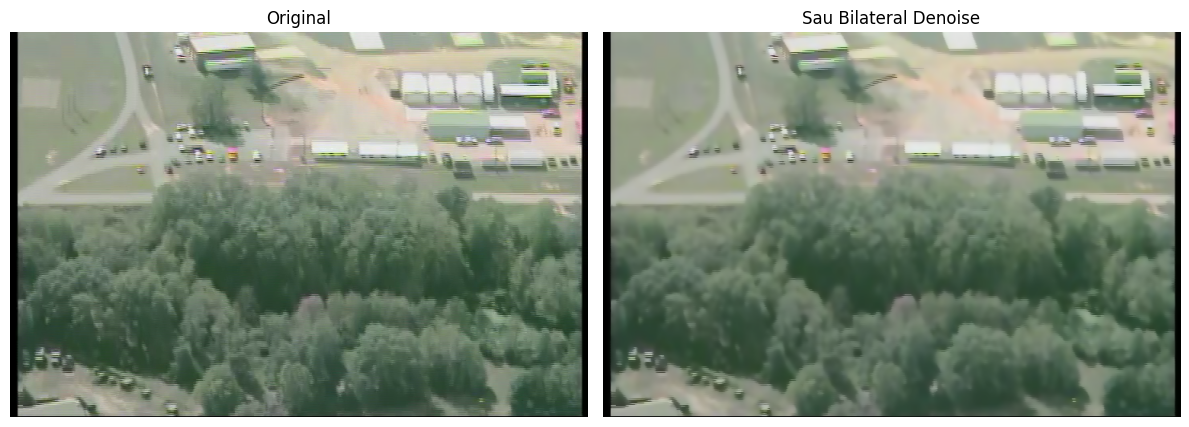

In [27]:
# So sánh trực quan: 1 frame mẫu trước / sau khử nhiễu
sample_name = frame_files[len(frame_files) // 2]

orig = cv2.cvtColor(cv2.imread(str(FRAMES_DIR / sample_name)), cv2.COLOR_BGR2RGB)
den  = cv2.cvtColor(cv2.imread(str(DENOISED_DIR / sample_name)), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(orig); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(den);  axes[1].set_title("Sau Bilateral Denoise"); axes[1].axis("off")
plt.tight_layout()
plt.show()

## 4. Bước 3 — Canny Edge Detection

Chạy `run_canny_pipeline` trên toàn bộ frame đã khử nhiễu. Kết quả gồm:
- Ảnh biên nhị phân (`edges/`)
- Ảnh overlay biên lên ảnh gốc để trực quan hóa (`edges_overlay/`)
- Edge ratio trung bình (in ra console)

In [28]:
run_canny_pipeline(
    input_dir=str(DENOISED_DIR),
    output_dir=str(EDGES_DIR),
    overlay_dir=str(OVERLAY_DIR),
    low_threshold=50,
    high_threshold=150,
    blur_kernel=5,
)

Found 30 frames in d:\PYTHON\cv\CP_Vsions\VideoSuperResolution\data\processed\denoised
Average edge ratio: 0.0159
Canny edge detection completed!


'd:\\PYTHON\\cv\\CP_Vsions\\VideoSuperResolution\\data\\processed\\edges'

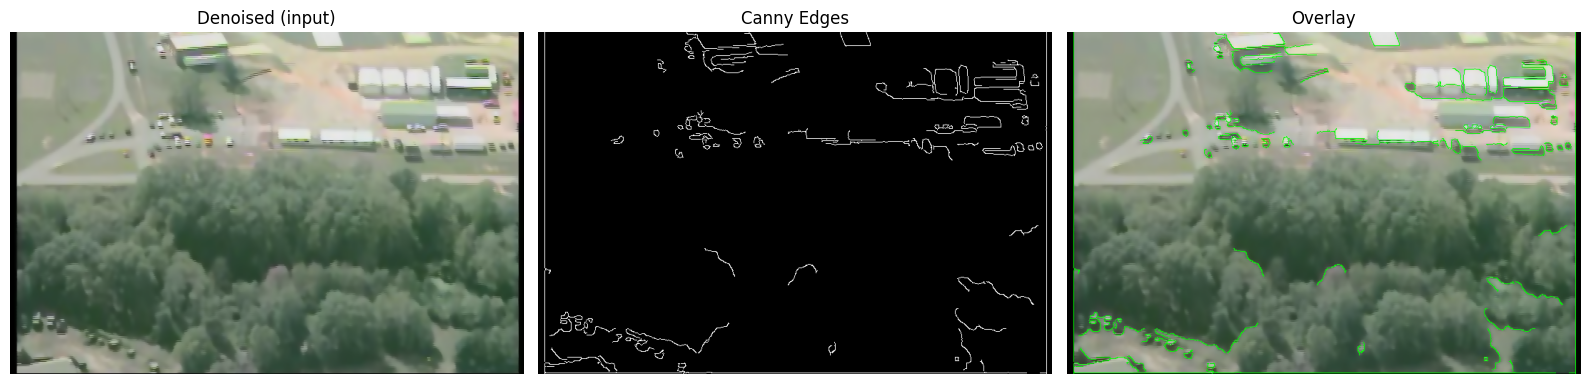

In [29]:
# Trực quan hóa: denoised -> edges -> overlay cho frame mẫu
edges   = cv2.imread(str(EDGES_DIR / sample_name), cv2.IMREAD_GRAYSCALE)
overlay = cv2.cvtColor(cv2.imread(str(OVERLAY_DIR / sample_name)), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(den);              axes[0].set_title("Denoised (input)"); axes[0].axis("off")
axes[1].imshow(edges, cmap="gray"); axes[1].set_title("Canny Edges");     axes[1].axis("off")
axes[2].imshow(overlay);          axes[2].set_title("Overlay");          axes[2].axis("off")
plt.tight_layout()
plt.show()

## 5. Khảo sát ngưỡng Canny (Threshold Survey)

Khảo sát ảnh hưởng của `low_threshold` / `high_threshold` lên kết quả biên, trên cùng 1 frame mẫu.
Kết quả xuất ra:
- `threshold_survey.csv` — edge ratio cho từng cặp (low, high)
- `threshold_survey_grid.png` — lưới ảnh so sánh trực quan

low=30   high=100  edge_ratio=0.0313
low=30   high=150  edge_ratio=0.0222
low=30   high=200  edge_ratio=0.0158
low=30   high=250  edge_ratio=0.0111
low=50   high=100  edge_ratio=0.0273
low=50   high=150  edge_ratio=0.0204
low=50   high=200  edge_ratio=0.0142
low=50   high=250  edge_ratio=0.0089
low=80   high=100  edge_ratio=0.0212
low=80   high=150  edge_ratio=0.0163
low=80   high=200  edge_ratio=0.0106
low=80   high=250  edge_ratio=0.0077
low=100  high=150  edge_ratio=0.0138
low=100  high=200  edge_ratio=0.0091
low=100  high=250  edge_ratio=0.0068

Saved grid comparison : d:\PYTHON\cv\CP_Vsions\VideoSuperResolution\reports\canny_threshold_survey\threshold_survey_grid.png
Saved CSV results     : d:\PYTHON\cv\CP_Vsions\VideoSuperResolution\reports\canny_threshold_survey\threshold_survey.csv


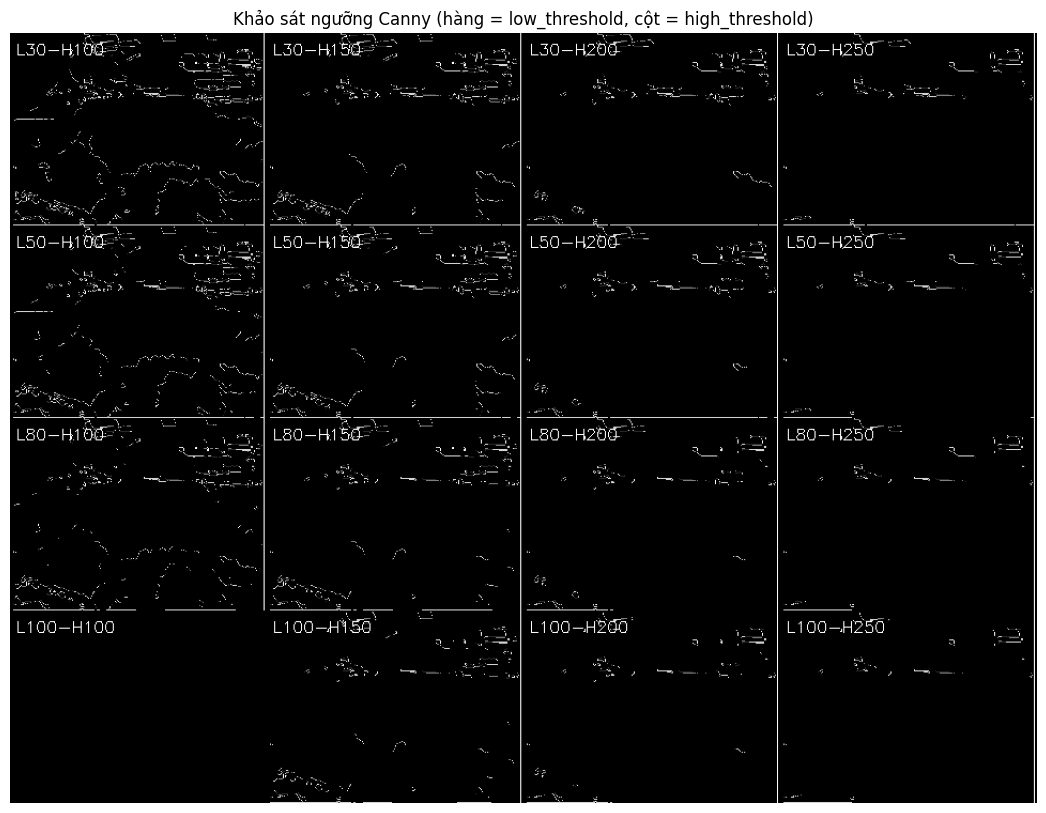

In [30]:
csv_path, grid_path = run_survey(
    image_path=str(DENOISED_DIR / sample_name),
    output_dir=str(SURVEY_DIR),
    blur_kernel=5,
)

grid_img = cv2.imread(grid_path, cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=(14, 10))
plt.imshow(grid_img, cmap="gray")
plt.axis("off")
plt.title("Khảo sát ngưỡng Canny (hàng = low_threshold, cột = high_threshold)")
plt.show()

In [11]:
# Bảng kết quả edge ratio, sắp xếp theo giá trị tăng dần
df = pd.read_csv(csv_path)
df.sort_values("edge_ratio").reset_index(drop=True)

,low_threshold,high_threshold,edge_ratio
0,100,250,0.0209
1,80,250,0.0235
2,100,200,0.0282
3,50,250,0.0287
4,30,250,0.0310
5,80,200,0.0320
6,100,150,0.0355
7,50,200,0.0382
8,80,150,0.0405
9,30,200,0.0416


## 6. Kiểm tra nhanh (sanity checks)

Vài assertion đơn giản để đảm bảo mỗi bước sinh đúng số lượng output — hữu ích khi chạy lại notebook trên video khác.

In [31]:
n_frames   = len([f for f in os.listdir(FRAMES_DIR) if f.lower().endswith((".png", ".jpg", ".jpeg"))])
n_denoised = len([f for f in os.listdir(DENOISED_DIR) if f.lower().endswith((".png", ".jpg", ".jpeg"))])
n_edges    = len([f for f in os.listdir(EDGES_DIR) if f.lower().endswith((".png", ".jpg", ".jpeg"))])

assert n_frames > 0, "Không tách được frame nào — kiểm tra lại đường dẫn video."
assert n_denoised == n_frames, "Số frame denoised không khớp số frame gốc."
assert n_edges == n_frames, "Số frame edges không khớp số frame gốc."

print("OK — tất cả bước đều sinh đủ", n_frames, "frame.")

OK — tất cả bước đều sinh đủ 30 frame.


## Tổng kết

| Bước | Output dir |
|---|---|
| Extract Frames | `data/frames/<video_name>/` |
| Denoising | `data/processed/denoised/` |
| Canny Edges | `data/processed/edges/` |
| Canny Overlay | `data/processed/edges_overlay/` |
| Threshold Survey | `reports/canny_threshold_survey/` |

**Bước tiếp theo trong pipeline:** Mean Shift Segmentation (`src/segmentation/`, chưa xây dựng).